In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.shape

(768, 9)

In [8]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [9]:
df.duplicated().sum()

np.int64(0)

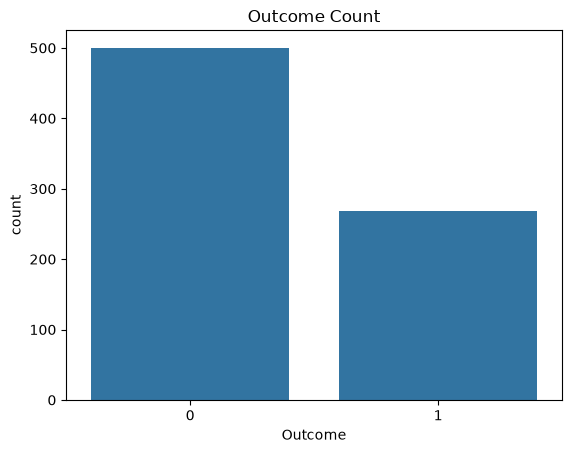

In [13]:
##  Check Class Distribution

df['Outcome'].value_counts()
sns.countplot(x='Outcome', data=df)
plt.title('Outcome Count')
plt.show()

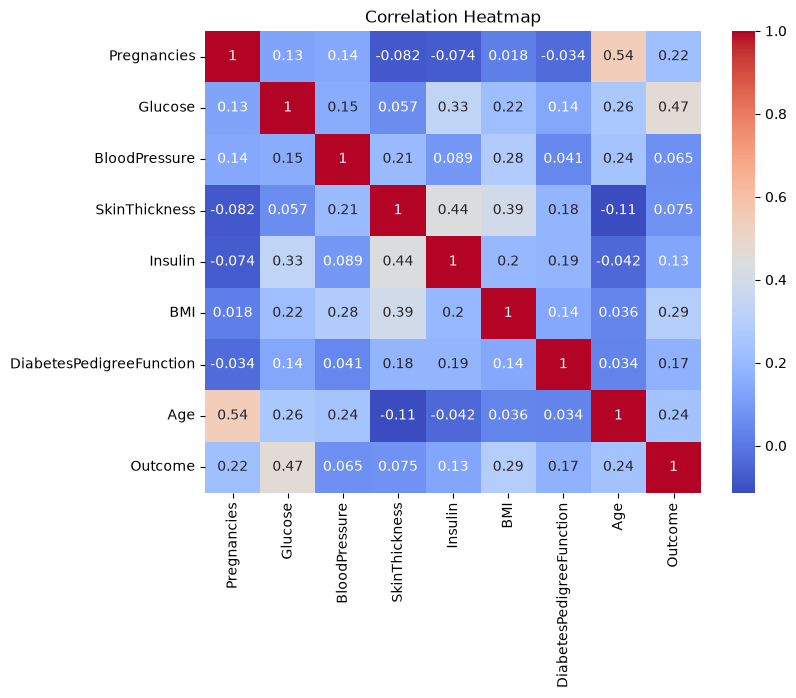

In [15]:
## Correlation Matrix

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),
annot=True, # Show correlation values
cmap="coolwarm") # Color theme
plt.title("Correlation Heatmap")
plt.show()

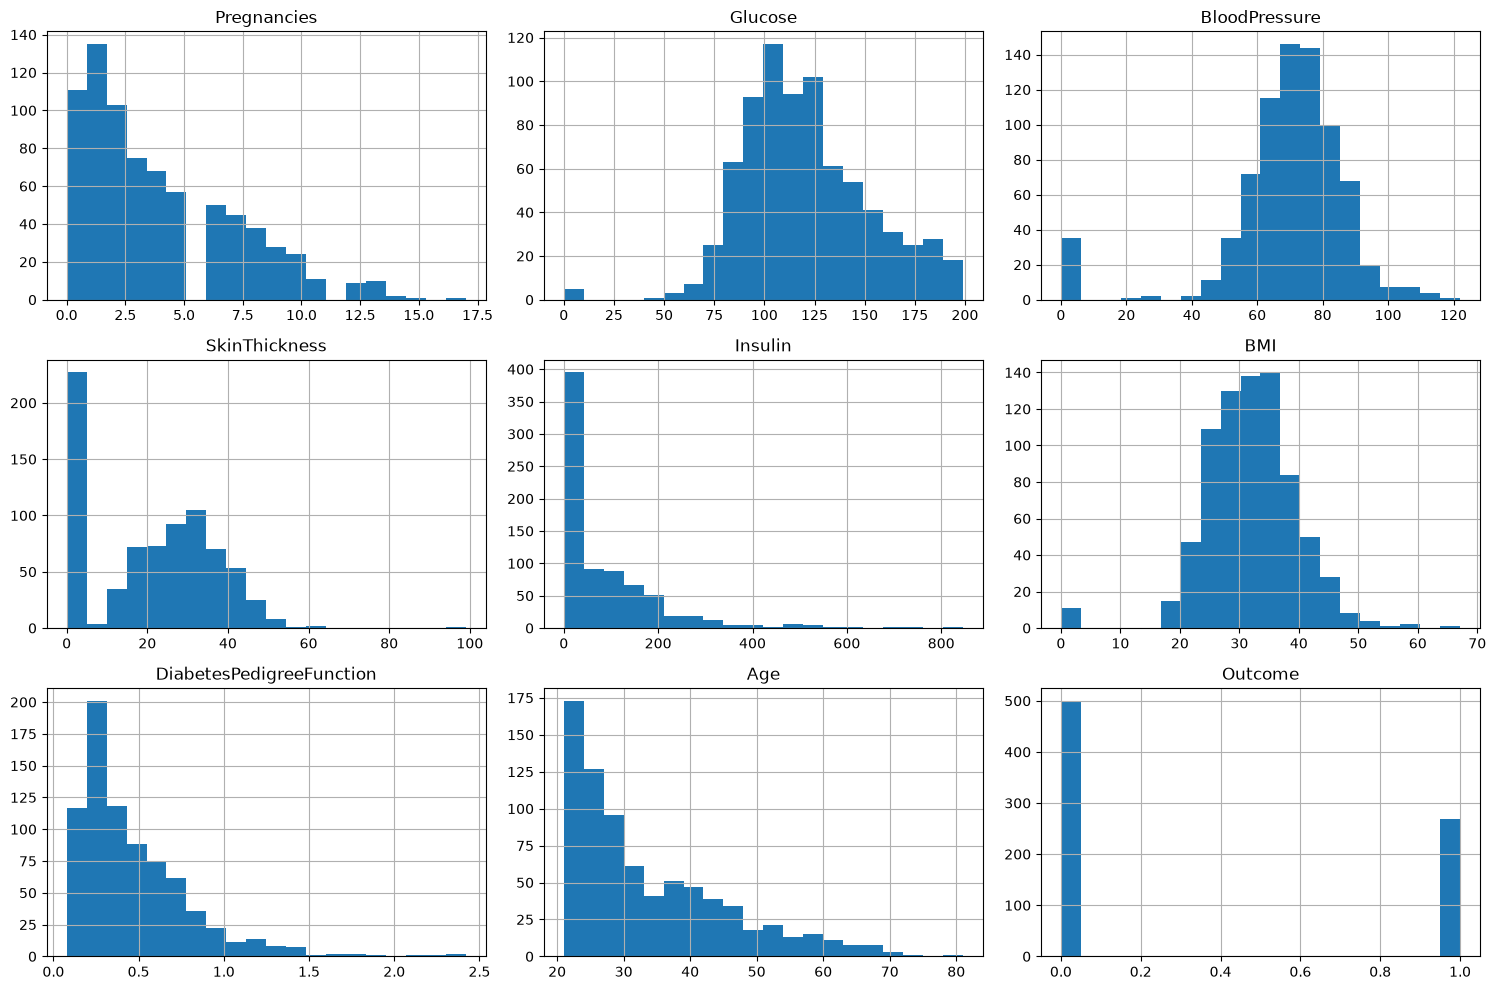

In [16]:
## Distribution of Features

df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

In [17]:
## Feature and Target Selection

X = df.drop('Outcome',axis=1)
y = df['Outcome']

## Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)  # 20% Testing Data and Same output every time

## Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)    # Learn scaling from training data
X_test = scaler.transform(X_test)   # Apply same scaling to testing data

## Build Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)    # Train the model

## Prediction
y_pred = model.predict(X_test)



In [18]:
## Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.7532467532467533


[[79 20]
 [18 37]]


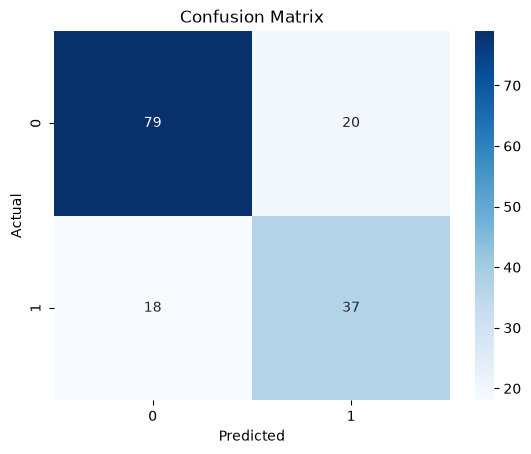

In [19]:
## Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [20]:
## Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



In [21]:
## Model Coefficients

coef = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_[0]})
print(coef)

                    Feature  Coefficient
0               Pregnancies     0.212554
1                   Glucose     1.071301
2             BloodPressure    -0.247826
3             SkinThickness     0.045729
4                   Insulin    -0.200783
5                       BMI     0.778182
6  DiabetesPedigreeFunction     0.230625
7                       Age     0.421207


In [23]:
## Predict New Patient

new_patient = [[2,120,70,25,100,30.5,0.45,35]]

# Scale new patient data
new_patient = scaler.transform(new_patient)    # Here the model is being tested, so no fit_transform
prediction = model.predict(new_patient)

if prediction[0] == 1:
    print("Diabetic")
else:
    print("Not Diabetic")

Not Diabetic


/Users/ayeshasiddiqha/AIProjects/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
